# Groundwater Decline vs ET:Precip Ratio (Regional Relationship Plotting)

This script visualizes the relationship between groundwater decline and the evapotranspiration-to-precipitation ratio across study sites. It loads precomputed site-level data, applies log-transformed regression by region, and generates annotated scatter plots with trend lines and statistical summaries.

In [10]:
# Import libraries
import numpy as np
import pandas as pd
import rasterio
import glob

from shapely.geometry import box
from pyproj import Transformer

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

## Buffer Size Change Notes (IMPORTANT)
This script depends on a precomputed dataset created using a spatial buffer (currently 1 km). If the buffer size changes (e.g., 2 km, 4 km, 10 km), you must update the following:
-   Input file path: `site_summary = "/capstone/aridgw/outputs/1km/site_summary_1km.csv"`
    -   Change 1km to new buffer size (e.g., 2km, 4km, 10km)

In [11]:
# Read in site summary data
site_summary = "/capstone/aridgw/outputs/1km/site_summary_1km.csv"
site_summary = pd.read_csv(site_summary)
site_summary.head()

,site_id,gw_trend_m_per_yr,region,mean_et,mean_precip,et_precip_ratio
0,KSGS.371852100505801,0.616701,Southern Kansas,797.106238,551.83820,1.444456
1,KSGS.372043101363101,0.213301,Southern Kansas,522.713143,514.42303,1.016115
2,KSGS.372539100142504,1.047972,Southern Kansas,829.910619,605.14417,1.371426
3,KSGS.373331098033301,0.063359,Southern Kansas,860.773810,929.18040,0.926380
4,KSGS.373607100565301,0.595615,Southern Kansas,616.277619,523.98620,1.176133


## Final Plot

/tmp/ipykernel_3258778/554588211.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Set1', len(regions))


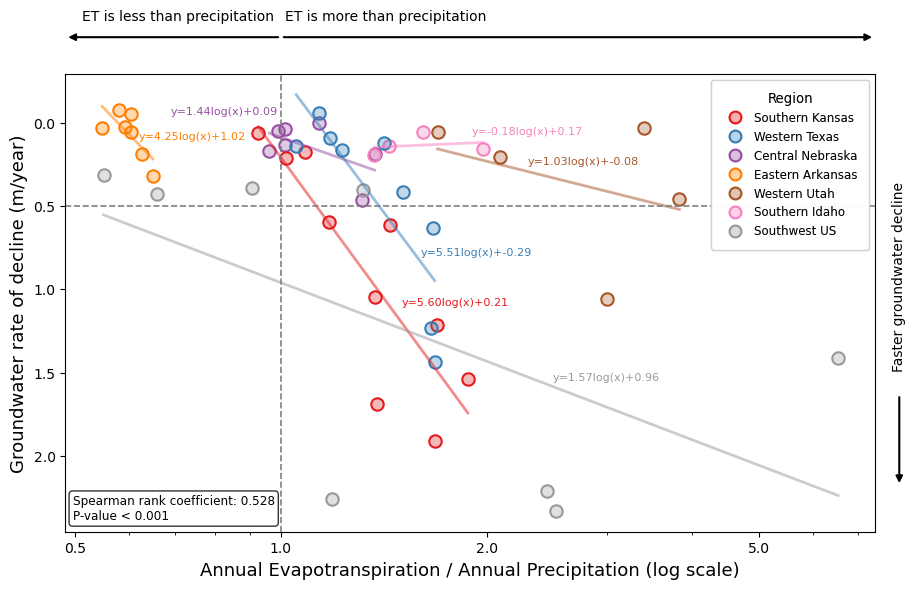

In [12]:
# Create final scatter plot with regression lines and annotations
fig, ax = plt.subplots(figsize=(10, 6))
# Assign consistent colors to each region
regions = site_summary["region"].unique()
colors = cm.get_cmap('Set1', len(regions))
color_map = {r: colors(i) for i, r in enumerate(regions)}

# Define manual label positions for regression equation text
label_positions = { "Southern Kansas": (1.5, 1.1), 
                   "Western Texas": (1.6, 0.8), 
                   "Central Nebraska": (0.69, -0.05), 
                   "Eastern Arkansas": (.62, 0.1), 
                   "Western Utah": (2.3, 0.25), 
                   "Southern Idaho": (1.9, 0.07), 
                   "Southwest US": (2.5, 1.55) 
}


# Loop through each region and plot data points
for region, group in site_summary.groupby("region"):
    
    base_color = color_map[region]
    face_color = mcolors.to_rgba(base_color, alpha=0.3)
    
    # Plot scatter points for each region
    ax.scatter(
        group["et_precip_ratio"],
        group["gw_trend_m_per_yr"],
        s=80,
        marker='o',
        facecolors=face_color,
        edgecolors=base_color,
        linewidths=1.5
    )    
    x = group["et_precip_ratio"].values
    y = group["gw_trend_m_per_yr"].values
    
    # Apply log transformation to X variable for regression
    log_x = np.log10(x)
    
    # Remove invalid values
    mask = np.isfinite(log_x) & np.isfinite(y)
    log_x = log_x[mask]
    y = y[mask]
    x = x[mask]
    
    if len(log_x) > 1:
        # Fit regression
        slope, intercept = np.polyfit(log_x, y, 1)
        
        # Generate regression line over data range
        x_line = np.linspace(min(x), max(x), 100)
        y_line = slope * np.log10(x_line) + intercept
        
        # Plot regression line
        ax.plot(x_line, y_line, color=base_color, linewidth=2, alpha=0.5)
        
        # Add regression equation label
        default_pos = (np.median(x), slope * np.log10(np.median(x)) + intercept)
        pos = label_positions.get(region, default_pos)
        ax.text(pos[0], pos[1], f"y={slope:.2f}log(x)+{intercept:.2f}",
                color=base_color, fontsize=8)

# Set axis labels and invert Y axis for interpretation
ax.set_xlabel("Annual Evapotranspiration / Annual Precipitation (log scale)", fontsize=13)
ax.set_ylabel("Groundwater rate of decline (m/year)", fontsize=13)
ax.invert_yaxis()

# Add right side annotation arrow for groundwater decline direction
ax.annotate(
    "",
    xy=(1.03, 0.1),
    xytext=(1.03, 0.3),
    xycoords="axes fraction",
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5)
)
ax.text(
    1.03, 0.35,
    "Faster groundwater decline",
    transform=ax.transAxes,
    ha="center", va="bottom",
    fontsize=10, color="black",
    rotation=90
)

# Add horizontal threshold line
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.2)

# Add vertical reference line at ET = Precipitation
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.2)

# Add top right direction arrow for ET dominance
ax.annotate(
    "",
    xy=(1, 1.08),
    xytext=(1, 1.08),
    xycoords=("axes fraction", "axes fraction"),
    textcoords=("data", "axes fraction"),
    arrowprops=dict(arrowstyle="-|>", lw=1.5, color="black")
)

# Add label for ET greater than precipitation
ax.text(0.52, 1.11, "ET is more than precipitation",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10)

# Add top left direction arrow for precipitation dominance
ax.annotate(
    "",
    xy=(0.00, 1.08),
    xytext=(1, 1.08),
    xycoords=("axes fraction", "axes fraction"),
    textcoords=("data", "axes fraction"),
    arrowprops=dict(arrowstyle="-|>", lw=1.5, color="black")
)

# Add label for ET less than precipitation
ax.text(0.02, 1.11, "ET is less than precipitation",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10)


# Create region legend with custom labels and styling
region_legend = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markersize=8.5,
        markerfacecolor=mcolors.to_rgba(color_map[r], alpha=0.3),
        markeredgecolor=color_map[r],                            
        markeredgewidth=1.5,
        label=r.replace("SoCal_Arizona", "Southwest US")
               .replace("Arkansas Delta", "Eastern Arkansas")
               .replace("_", " ")
    )
    for r in regions
]

# Add legend to plot
legend1 = ax.legend(handles=region_legend, 
                    title="Region", 
                    loc="upper right",
                    fontsize=8.5,
                    title_fontsize=9.5,
                    borderpad=1,
                    labelspacing=0.5,
                    handletextpad=0.6)

ax.add_artist(legend1)

# Set x axis to Log scale
ax.set_xscale('log')

# Define custom X axis ticks
ax.set_xticks([0.5, 1, 2, 5])
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

# Add spearman correlation text box
ax.text(0.009, 0.02, "Spearman rank coefficient: 0.528\nP-value < 0.001",
        transform=ax.transAxes, fontsize=8.7,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Adjust layout for better spacing
plt.tight_layout()
plt.subplots_adjust(right=0.88)  # make room for right side arrow
plt.show()

## Raw plot

/tmp/ipykernel_3258778/2581777821.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Set1', len(regions))


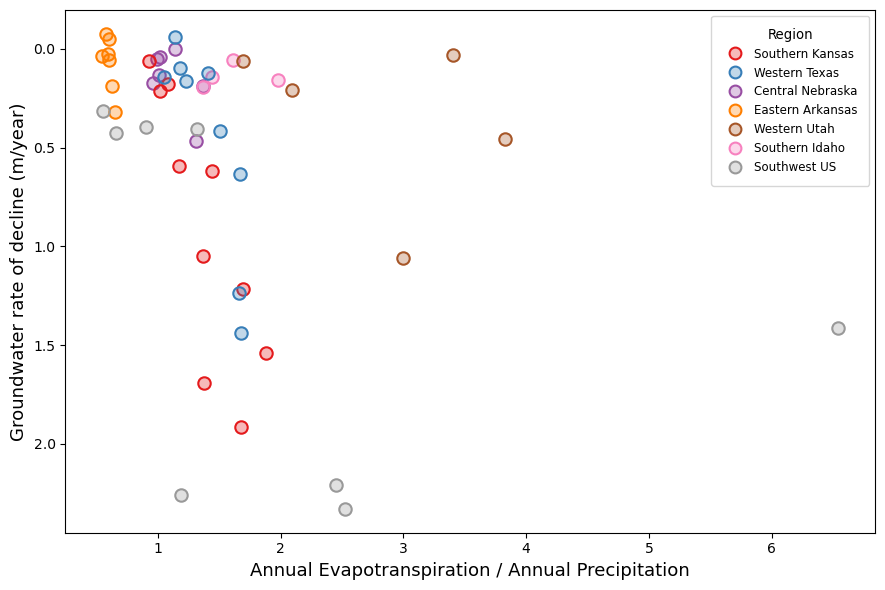

In [13]:
# Create raw scatter plot without regression or annotations
fig, ax = plt.subplots(figsize=(10, 6))

# Reassign region colors for consistency
regions = site_summary["region"].unique()
colors = cm.get_cmap('Set1', len(regions))
color_map = {r: colors(i) for i, r in enumerate(regions)}

# Plot raw data points for each region
for region, group in site_summary.groupby("region"):
    base_color = color_map[region]
    face_color = mcolors.to_rgba(base_color, alpha=0.3)
    
    ax.scatter(
        group["et_precip_ratio"],
        group["gw_trend_m_per_yr"],
        s=80,
        marker='o',
        facecolors=face_color,
        edgecolors=base_color,
        linewidths=1.5
    )

# Set axis labels for raw plot
ax.set_xlabel("Annual Evapotranspiration / Annual Precipitation", fontsize=13)
ax.set_ylabel("Groundwater rate of decline (m/year)", fontsize=13)
ax.invert_yaxis()

# Create legend for raw plot regions
region_legend = [
    Line2D([0], [0], marker='o', linestyle='None', markersize=8.5,
        markerfacecolor=mcolors.to_rgba(color_map[r], alpha=0.3),
        markeredgecolor=color_map[r], markeredgewidth=1.5,
        label=r.replace("SoCal_Arizona", "Southwest US")
               .replace("Arkansas Delta", "Eastern Arkansas")
               .replace("_", " "))
    for r in regions
]

# Add legend to raw plot
ax.legend(handles=region_legend, title="Region", loc="upper right",
    fontsize=8.5, title_fontsize=9.5, borderpad=1, labelspacing=0.5, handletextpad=0.6)

# Final layout adjustment
plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.show()